# Dist3 (C3 スプリッタ) SM の受理ドメインと「谷」— なぜ r3 が最大の失敗か

**問い**: #201 run の失敗内訳は 反応器 **r_rx ~40%** が最多で、**r3 (Dist3 SM classifier infeasible) ~24%** が 2 番目。
r3 失敗は Dist3 SM(学習済み GaussianProcess + RandomForest classifier)の**受理ドメイン**と、
catofin フローが膜から渡す Dist3 フィードの**不一致**で起きる。本ノートでそれを可視化・定量化し、
**best #201 自体は高流量域(受理頑健)に着地**する一方で、off-best trial が谷に落ちる構図を示す。

Dist3 SM の入力 5 つ: `In_Total_Stages, In_Feed_Stage, In_Column_P[kPa], In_Flow[kgmol/s], In_Propane(C3H8分率)`。
学習域(`models/column3_sm.pkl` の bounds): In_Flow 0.361–0.5, In_Propane 0.05–0.20。
`_predict` は入力を bounds に clamp してから classifier で feasibility 判定する。HYSYS 不要(SM/分類器のみ)。


In [1]:
import os, sys, pickle, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
# RandomForest classifier は predict 毎に sklearn parallel.delayed UserWarning を出すため
# (受理面の格子評価で 1000 回超 → notebook が肥大化)、本ノートでは抑制する。結果には影響しない。
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

m = pickle.load(open(os.path.join(ROOT, 'models', 'column3_sm.pkl'), 'rb'))
cols = list(m['input_columns']); clf = m['classifier']; b = m['bounds']
print('input_columns :', cols)
print('In_Flow 学習域 :', tuple(round(x,3) for x in b['In_Flow']), 'kgmol/s')
print('In_Propane学習域:', b['In_Propane'])
print('training_rows :', m.get('training_rows'), ' feasible_rows :', m.get('feasible_rows'))

def clamp(x):
    y = dict(x)
    for c in cols:
        lo, hi = b[c]; y[c] = min(max(y[c], lo), hi)
    return y

def feas(N, P, flow, prop, fr=0.75):
    x = clamp({'In_Total_Stages': N, 'In_Feed_Stage': int(round(fr*N)),
               'In_Column_P': P, 'In_Flow': flow, 'In_Propane': prop})
    return bool(clf.predict(pd.DataFrame([[x[c] for c in cols]], columns=cols))[0])

input_columns : ['In_Total_Stages', 'In_Feed_Stage', 'In_Column_P', 'In_Flow', 'In_Propane']
In_Flow 学習域 : (0.361, 0.5) kgmol/s
In_Propane学習域: (0.05, 0.2)
training_rows : 248  feasible_rows : 123


## §1. classifier 受理面 (In_Flow × In_Propane)

N=117, P=1675kPa(#201 設計点)で、In_Flow と In_Propane を振って classifier の feasible 域を描く。
**catofin #201 が膜から渡す Dist3 フィード**(実測: In_Flow≈0.562, In_Propane≈0.014)を重ねる。
In_Flow=0.562 は SM 学習域上限 0.5 を**超えており clamp される**(= 流量方向は外挿)。


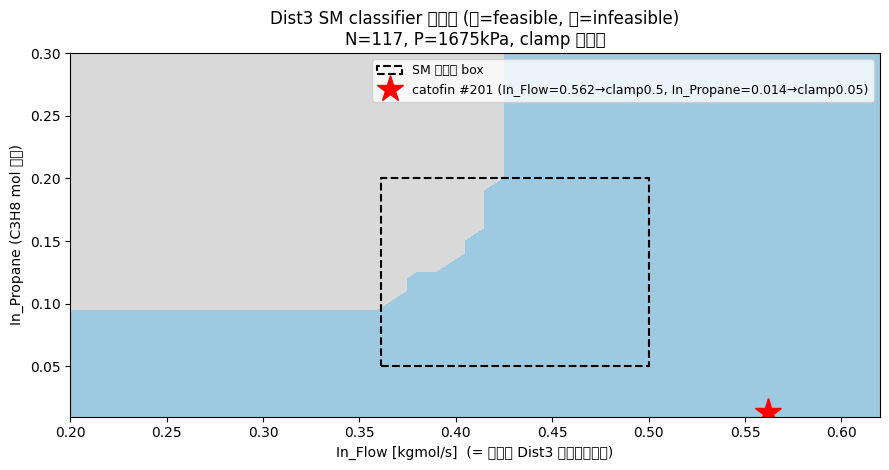

受理パターン (clamp 後):
  低流量 (In_Flow<=0.36): In_Propane<=0.05 の超高純度コーナーのみ受理
  高流量 (In_Flow>=0.45): In_Propane 不問で受理
  → 中流量×中propane の「谷」が NG。catofin #201 は高流量(0.562→clamp0.5)側で頑健に受理。


In [2]:
flows = np.linspace(0.20, 0.62, 43)
props = np.linspace(0.01, 0.30, 30)
Z = np.array([[1 if feas(117, 1675, fl, pr) else 0 for fl in flows] for pr in props])

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.contourf(flows, props, Z, levels=[-0.5, 0.5, 1.5], colors=['0.85', '#9ecae1'])
ax.axvspan(b['In_Flow'][0], b['In_Flow'][1], ymin=0, ymax=1, color='none', ec='k', lw=0)
# 学習域ボックス
import matplotlib.patches as mp
ax.add_patch(mp.Rectangle((b['In_Flow'][0], b['In_Propane'][0]),
                          b['In_Flow'][1]-b['In_Flow'][0], b['In_Propane'][1]-b['In_Propane'][0],
                          fill=False, ec='k', ls='--', lw=1.5, label='SM 学習域 box'))
# catofin #201 の着地点 (In_Flow=0.562 は学習域上限0.5を超え、clamp される)
ax.plot(0.562, 0.014, 'r*', ms=20, label='catofin #201 (In_Flow=0.562→clamp0.5, In_Propane=0.014→clamp0.05)')
ax.set_xlabel('In_Flow [kgmol/s]  (= 膜透過 Dist3 フィード流量)')
ax.set_ylabel('In_Propane (C3H8 mol 分率)')
ax.set_title('Dist3 SM classifier 受理面 (青=feasible, 灰=infeasible)\nN=117, P=1675kPa, clamp 後判定')
ax.legend(loc='upper right', fontsize=9); plt.tight_layout(); plt.show()

print('受理パターン (clamp 後):')
print('  低流量 (In_Flow<=0.36): In_Propane<=0.05 の超高純度コーナーのみ受理')
print('  高流量 (In_Flow>=0.45): In_Propane 不問で受理')
print('  → 中流量×中propane の「谷」が NG。catofin #201 は高流量(0.562→clamp0.5)側で頑健に受理。')

## §2. N・P 依存

clamp 済み入力で、段数 N と 圧力 P を振って受理を見る(In_Flow/In_Propane は #201 着地点に固定)。


In [3]:
Ns = [115, 117, 120, 130, 150, 160]; Ps = [1600, 1675, 1700, 1800, 1900]
print('N \\ P   ' + '  '.join(f'{p:>5}' for p in Ps))
for N in Ns:
    row = '  '.join(' ok ' if feas(N, p, 0.562, 0.014) else ' NG ' for p in Ps)
    print(f'  {N:>3}   {row}')
print('\n→ #201 着地点(0.562/0.014→clamp0.5/0.05)は高流量域なので N・P によらず広く受理。')
print('  問題は N でなく In_Flow/In_Propane の谷 (中流量×中propane)。')

N \ P    1600   1675   1700   1800   1900


  115    ok    ok    ok    ok    ok 


  117    ok    ok    ok    ok    ok 


  120    ok    ok    ok    ok    ok 


  130    ok    ok    ok    ok    ok 


  150    ok    ok    ok    ok    ok 


  160    ok    ok    ok    ok    ok 

→ #201 着地点(0.562/0.014→clamp0.5/0.05)は高流量域なので N・P によらず広く受理。
  問題は N でなく In_Flow/In_Propane の谷 (中流量×中propane)。


## §3. 結論と対処方向

- Dist3 SM の受理は **(a) In_Flow≥0.45(高流量, propane不問)** か **(b) 低流量×超高純度(In_Propane≤0.05)** の2択で、
  間の**谷(中流量×中propane)が NG**。谷は学習域の**内側**(= 学習時に HYSYS が収束しなかった実infeasible)。
- **#201 では best の Dist3 フィードが高流量**(In_Flow≈0.562, In_Propane≈0.014)で、**高流量域に着地して頑健に受理**される。
  旧 #227(低流量 0.338 × 超高純度コーナーでギリ通過)から、best の着地点が**安全側へ移動**した
  (#201 は生産 1194 kmol/h + 高リサイクルで Dist3 フィード流量が大きいため)。
- **ただし In_Flow≈0.562 は SM 学習上限 0.5(=1800 kmol/h)を超える外挿で clamp されている**。流量方向は
  SM の補間範囲外なので、Dist3 出力(Q_reb/Q_cond/分配)の妥当性は **model-validity 上の残課題**。
- それでも **off-best trial は QMC で谷(中流量×中propane)に落ち、r3 は全失敗の ~24%(2 番目)**。
  最多失敗は **反応器 r_rx ~40%**(SV/ΔP 制約)に移っており、r3 は最大要因ではなくなった。
- **対処**: 谷は学習域内=実 infeasible のため classifier を緩めるのは危険(外挿で偽 TAC を掴む)。
  流量上端の外挿は **(i) SM を高流量側(In_Flow>0.5)で HYSYS 再サンプリングして学習域を拡張**するか、
  **(ii) A_mem/F_fresh を絞って Dist3 フィード流量を学習域内(≤0.5=1800 kmol/h)に保つ設計**にすることで解消する。
  Dist3 rigorous 化は N=117・微小 α(C3H6/C3H8≈1.07)で収束困難・低速(= そもそも SM 化した動機)のため非現実的で採らない。

> 本ノートは SM/classifier のみ(HYSYS 不要)。受理面は `models/column3_sm.pkl` の学習結果。
